# Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 2. Hyperparameters

In [ ]:
batch_size = 128
learning_rate = 0.001
epochs = 20

input_dim = 32 * 32 * 3
hidden_dim = 512

sparsity_target = 0.05
sparsity_weight = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Explanation

This section defines the **training configuration and model parameters**.

| Parameter | Description |
|----------|-------------|
| batch_size | Number of images processed per training iteration |
| learning_rate | Controls how fast model weights are updated |
| epochs | Number of times the dataset is used during training |
| input_dim | Flattened CIFAR-10 image size (3072) |
| hidden_dim | Size of compressed feature representation |
| sparsity_target | Desired average activation of hidden neurons |
| sparsity_weight | Strength of sparsity regularization |

# 3.Load and Preprocess CIFAR-10 Dataset

In [ ]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 170M/170M [00:15<00:00, 10.7MB/s]


### Explanation

Images are preprocessed before being fed to the network.

1. **ToTensor()**
   - Converts image pixels into PyTorch tensors.
   - Pixel values scaled from `[0,255]` to `[0,1]`.

2. **Normalize()**
   - Normalizes images around zero.
   - Helps neural networks train faster and more stably.

---

# Loading CIFAR-10 Dataset

### Explanation

This loads the **CIFAR-10 dataset**, which contains:

- **60,000 images**
- **10 object classes**
- Image size: **32 × 32 × 3**

Two datasets are created:

- **Training dataset**
- **Testing dataset**

---

`DataLoader` loads images in **mini-batches** during training.

Benefits:

- Efficient memory usage
- Faster training
- Automatic batching

Parameters used:

- **batch_size** – number of samples per batch
- **shuffle=True** – randomizes training samples

# 4. Sparse Autoencoder Model

In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

### Explanation

The autoencoder consists of two parts:

#### Encoder
Compresses the input image:

```
3072 → 512
```

It learns a **compact feature representation** of the input.

#### Decoder
Reconstructs the original image:

```
512 → 3072
```

It attempts to reproduce the input image from the compressed representation.


# 5. Sparsity Penalty Function

In [ ]:
def sparsity_loss(encoded):

    eps = 1e-8

    rho_hat = torch.mean(encoded, dim=0)
    rho = torch.full_like(rho_hat, sparsity_target)

    rho_hat = torch.clamp(rho_hat, eps, 1 - eps)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)


### Explanation

Sparse autoencoders encourage **neurons to activate rarely**.

This is achieved using **KL Divergence**, which measures the difference between:

- Desired sparsity $ \rho $
- Actual neuron activation $ \hat{\rho} $

Loss function used during training:

$$
L = L_{\text{reconstruction}} + \lambda L_{\text{sparsity}}
$$

Where:

- $L_{\text{reconstruction}}$ = Mean Squared Error (MSE)
- $L_{\text{sparsity}}$ = KL divergence sparsity penalty
- $\lambda$ = sparsity regularization weight

# 6. Model Initialization

In [ ]:
model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
sparsity_values = [0, 1e-5, 1e-4, 1e-3]

results = {}

### Explanation

- **SparseAutoencoder()** – initializes the model
- **MSELoss()** – measures reconstruction error
- **Adam optimizer** – updates weights efficiently


# 7. Training the Autoencoder

In [ ]:
def train_model(sparsity_weight):

    model = SparseAutoencoder().to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            encoded, outputs = model(images)

            recon_loss = criterion(outputs, images)

            sp_loss = sparsity_loss(encoded)

            loss = recon_loss + sparsity_weight * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Sparsity {sparsity_weight} | Epoch {epoch+1} Loss {total_loss:.2f}")

    # test loss
    model.eval()
    test_loss = 0

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.view(images.size(0), -1).to(device)

            _, outputs = model(images)

            loss = criterion(outputs, images)

            test_loss += loss.item()

    return model, test_loss

### Explanation

Training process:

1. Images are **flattened into vectors**
2. Data passes through **encoder → decoder**
3. Two losses are calculated:
   - Reconstruction Loss
   - Sparsity Loss
4. Gradients are computed using **backpropagation**
5. Optimizer updates network weights


# Run Experiments

In [ ]:
models = {}

for s in sparsity_values:

    print("\nRunning experiment with sparsity =", s)

    model, test_loss = train_model(s)

    results[s] = test_loss
    models[s] = model


Running experiment with sparsity = 0
Sparsity 0 | Epoch 1 Loss 80.13
Sparsity 0 | Epoch 2 Loss 68.87
Sparsity 0 | Epoch 3 Loss 65.44
Sparsity 0 | Epoch 4 Loss 63.67
Sparsity 0 | Epoch 5 Loss 62.48
Sparsity 0 | Epoch 6 Loss 61.65
Sparsity 0 | Epoch 7 Loss 61.09
Sparsity 0 | Epoch 8 Loss 60.60
Sparsity 0 | Epoch 9 Loss 60.21
Sparsity 0 | Epoch 10 Loss 59.91
Sparsity 0 | Epoch 11 Loss 59.67
Sparsity 0 | Epoch 12 Loss 59.41
Sparsity 0 | Epoch 13 Loss 59.25
Sparsity 0 | Epoch 14 Loss 59.08
Sparsity 0 | Epoch 15 Loss 58.95
Sparsity 0 | Epoch 16 Loss 58.83
Sparsity 0 | Epoch 17 Loss 58.72
Sparsity 0 | Epoch 18 Loss 58.62
Sparsity 0 | Epoch 19 Loss 58.53
Sparsity 0 | Epoch 20 Loss 58.44

Running experiment with sparsity = 1e-05
Sparsity 1e-05 | Epoch 1 Loss 81.12
Sparsity 1e-05 | Epoch 2 Loss 69.81
Sparsity 1e-05 | Epoch 3 Loss 66.41
Sparsity 1e-05 | Epoch 4 Loss 64.60
Sparsity 1e-05 | Epoch 5 Loss 63.40
Sparsity 1e-05 | Epoch 6 Loss 62.57
Sparsity 1e-05 | Epoch 7 Loss 61.94
Sparsity 1e-05 | 

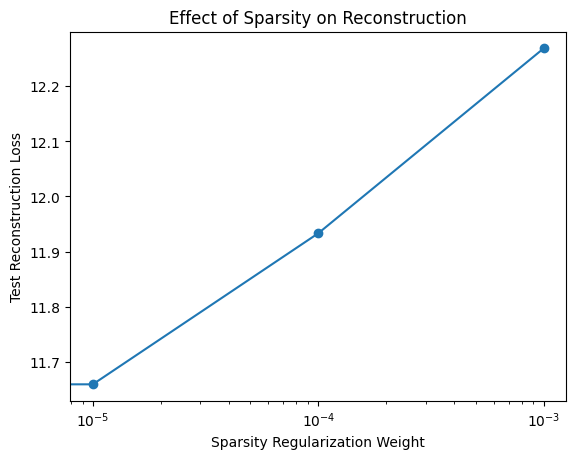

In [ ]:
import matplotlib.pyplot as plt

x = list(results.keys())
y = list(results.values())

plt.plot(x, y, marker='o')

plt.xscale("log")

plt.xlabel("Sparsity Regularization Weight")
plt.ylabel("Test Reconstruction Loss")

plt.title("Effect of Sparsity on Reconstruction")

plt.show()

# 8. Evaluate on Test Data

In [ ]:
criterion = nn.MSELoss()

for sparsity, model in models.items():

    model.eval()

    test_loss = 0

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.view(images.size(0), -1).to(device)

            _, outputs = model(images)

            loss = criterion(outputs, images)

            test_loss += loss.item()

    print(f"Sparsity {sparsity} → Test Reconstruction Loss: {test_loss:.4f}")

Sparsity 0 → Test Reconstruction Loss: 11.6798
Sparsity 1e-05 → Test Reconstruction Loss: 11.6594
Sparsity 0.0001 → Test Reconstruction Loss: 11.9331
Sparsity 0.001 → Test Reconstruction Loss: 12.2684


### Explanation

The trained model is evaluated on **test data**.

- `model.eval()` switches the model to evaluation mode
- `torch.no_grad()` disables gradient computation
- Reconstruction loss is calculated for unseen images

## Reconstruction Loss Comparison

| Sparsity Weight | Test Reconstruction Loss |
|----------------|--------------------------|
| 0              | 11.6798                  |
| 1e-5           | 11.6594                  |
| 1e-4           | 11.9331                  |
| 1e-3           | 12.2684                  |

### Observation

The reconstruction loss increases as the sparsity regularization weight increases.

- **Lowest Loss:** `1e-5`
- **Highest Loss:** `1e-3`

This indicates that stronger sparsity constraints slightly reduce the model's ability to reconstruct images accurately.

---


# 9. Visualize Original vs Reconstructed Images

In [ ]:
def visualize(model, sparsity):

    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    images = images.to(device)

    flat = images.view(images.size(0), -1)

    _, outputs = model(flat)

    outputs = outputs.view(-1,3,32,32)

    fig, axes = plt.subplots(2,6, figsize=(12,4))

    for i in range(6):

        axes[0,i].imshow(images[i].cpu().permute(1,2,0)*0.5 + 0.5)
        axes[0,i].set_title("Original")
        axes[0,i].axis("off")

        axes[1,i].imshow(outputs[i].cpu().detach().permute(1,2,0)*0.5 + 0.5)
        axes[1,i].set_title("Recon")
        axes[1,i].axis("off")

    plt.suptitle(f"Sparsity Weight = {sparsity}")
    plt.show()

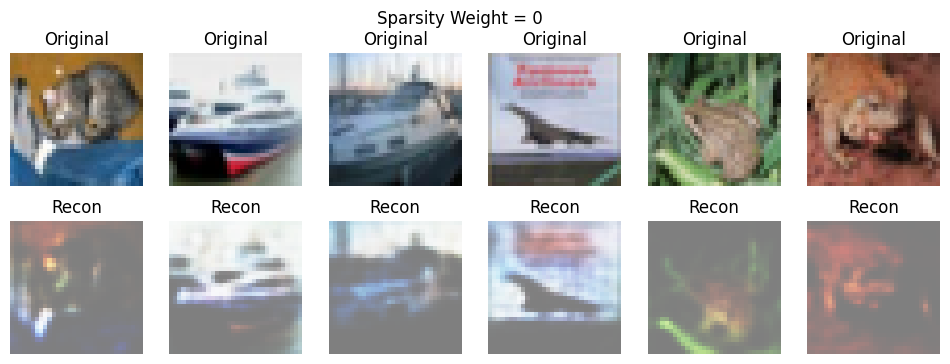

In [ ]:
visualize(models[0], 0)


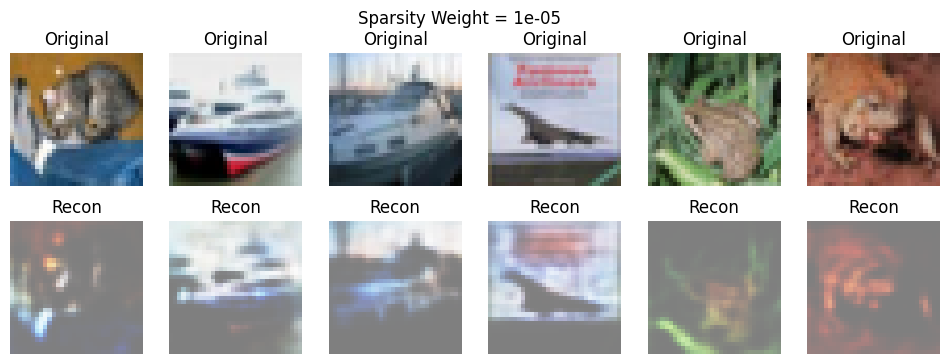

In [ ]:
visualize(models[1e-5], 1e-5)


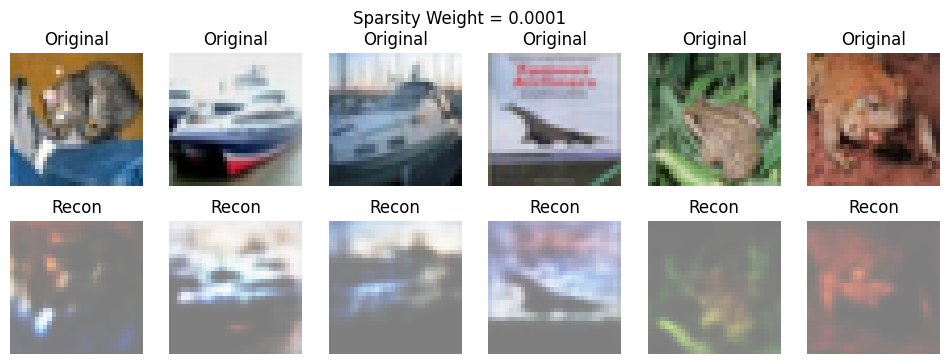

In [ ]:
visualize(models[1e-4], 1e-4)

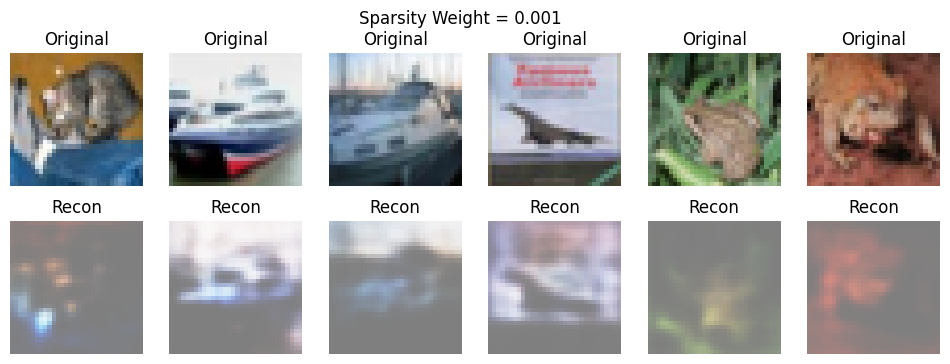

In [ ]:

visualize(models[1e-3], 1e-3)

# Interpretation of Sparse Autoencoder Results



# Visual Reconstruction Analysis

The figures show original CIFAR-10 images in the first row and reconstructed images in the second row for different sparsity weights.

## Case 1 — Sparsity Weight = 0

- No sparsity constraint is applied.
- The autoencoder focuses purely on minimizing reconstruction error.
- Reconstructions are relatively clearer compared to higher sparsity values.

**Observation:**  
The model uses many active neurons, allowing it to capture more information about the image.

---

## Case 2 — Sparsity Weight = 1e-5

- A very small sparsity constraint is introduced.
- Reconstruction quality remains almost the same as the previous case.

**Observation:**  
This value provides a good balance between reconstruction accuracy and sparse feature learning.

---

## Case 3 — Sparsity Weight = 1e-4

- The sparsity constraint becomes stronger.
- Reconstructions appear more blurred and slightly darker.

**Observation:**  
More neurons are forced to remain inactive, reducing the model's ability to represent detailed image features.

---

## Case 4 — Sparsity Weight = 1e-3

- A strong sparsity constraint is applied.
- Reconstruction quality degrades significantly.
- Images become darker and lose structural details.

**Observation:**  
Too many neurons are forced to stay inactive, resulting in insufficient information to reconstruct the image accurately.

---

# Overall Interpretation

The experiment demonstrates the trade-off between **sparsity and reconstruction quality**.

- Low sparsity values allow better reconstruction but fewer sparse features.
- High sparsity values encourage sparse representations but reduce reconstruction quality.

### Total Loss Function

The total loss optimized by the model is:

$$
L = L_{\text{reconstruction}} + \lambda L_{\text{sparsity}}
$$

Where:

- $L_{\text{reconstruction}}$ represents the Mean Squared Error between the input and reconstructed images.
- $L_{\text{sparsity}}$ enforces sparse activation of hidden neurons.
- $\lambda$ controls the strength of sparsity regularization.

---

# Conclusion

From the experiment:

- A **very small sparsity weight (1e-5)** provides the best balance between feature sparsity and reconstruction accuracy.
- Larger sparsity values force the network to activate fewer neurons, which limits its ability to represent image details.
- Therefore, moderate sparsity regularization helps the autoencoder learn meaningful feature representations while maintaining acceptable reconstruction quality.